# 🌳 Árbol de Decisión — Regresión de Dimensiones Espaciales (NASA)

Análisis sistemático usando `DecisionTreeRegressor` para predecir el diámetro de un objeto espacial a partir de su magnitud absoluta. Se evalúa la precisión del modelo en tres particiones (80/20, 70/30, 60/40).

**Variable predictora (X):** `brillo_relativo` (Magnitud Absoluta * -1)  
**Variable objetivo (Y):** `raiz_diametro_promedio`  

**Pipeline ETL NASA NeoWs** — Datos reales procesados para modelado predictivo de dimensiones físicas.

## I. Configuración Inicial — Importaciones y Estilo Visual

In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

from scripts.database import engine

# Estilo visual consistente con el proyecto
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")

✅ Librerías importadas correctamente
   pandas  2.3.3
   numpy   2.4.3
   seaborn 0.13.2


## II. Carga de Datos desde PostgreSQL

Consultamos la tabla `neows_registros` desde Supabase mediante el motor de conexión. Extraemos la magnitud absoluta y las dimensiones de los objetos para realizar una estimación técnica de su tamaño físico (regresión), permitiendo predecir la escala del asteroide a partir de su brillo capturado.

**Variable predictora (X):** `brillo_relativo` (Magnitud Absoluta * -1)  
**Variable objetivo (Y):** `raiz_diametro_promedio`

**Pipeline ETL WeatherStack (NASA Edition)** — datos reales obtenidos de la API de la NASA y centralizados en PostgreSQL (Supabase).

In [2]:
# ── CELDA 2: Carga de datos desde PostgreSQL (Nombres Reales - Regresión) ────
QUERY = """
SELECT
    diametro_min_km,
    diametro_max_km,
    magnitud_absoluta
FROM neows_registros
"""

# Cargar los datos desde Supabase / PostgreSQL
df = pd.read_sql(QUERY, engine)

# Renombrar columnas para coincidir con la lógica de regresión
# Eliminamos 'es_peligroso' ya que ahora el objetivo es predecir dimensiones
df.rename(columns={
    'diametro_min_km':   'Diametro_Min',
    'diametro_max_km':   'Diametro_Max',
    'magnitud_absoluta': 'Magnitud_Absoluta',
}, inplace=True)

print(f"✅ Datos cargados correctamente para el modelo de Regresión")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n📋 Valores nulos encontrados:")
print(df.isnull().sum())
print(f"\n📋 Vista previa de los datos (Raw):")
df.head()

✅ Datos cargados correctamente para el modelo de Regresión
   Filas    : 2,000
   Columnas : 3

📋 Valores nulos encontrados:
Diametro_Min         0
Diametro_Max         0
Magnitud_Absoluta    0
dtype: int64

📋 Vista previa de los datos (Raw):


,Diametro_Min,Diametro_Max,Magnitud_Absoluta
0,0.066459,0.148607,23.01
1,0.163891,0.366471,21.05
2,0.029144,0.065169,24.80
3,0.004837,0.010815,28.70
4,0.003346,0.007482,29.50


In [3]:
# ── CELDA 3: Ingeniería de Variables y Vectores X / Y (Regresión) ─────────────

# 1. Variable Objetivo (Y): Raíz del Diámetro Promedio
# Calculamos el promedio de los diámetros y aplicamos raíz para normalizar
df['raiz_diametro_promedio'] = np.sqrt((df['Diametro_Min'] + df['Diametro_Max']) / 2)

# 2. Variable Predictora (X): Brillo Relativo
# Convertimos la Magnitud Absoluta a Brillo Relativo (Magnitud * -1)
# Esto crea una correlación positiva: a mayor brillo, mayor tamaño.
df['brillo_relativo'] = df['Magnitud_Absoluta'] * -1

# 3. Selección de Vectores para el Modelo de Regresión
X = df[['brillo_relativo']].values
y = df['raiz_diametro_promedio'].values

# 4. Resumen de la preparación
print(f"✅ Vectores listos para Regresión")
print(f"   X (Predictora) : Brillo Relativo (Magnitud * -1)")
print(f"   y (Objetivo)   : Raíz del Diámetro Promedio")

print(f"\n📊 Estadísticas descriptivas del nuevo enfoque:")
display(df[['brillo_relativo', 'raiz_diametro_promedio']].describe().round(4))

✅ Vectores listos para Regresión
   X (Predictora) : Brillo Relativo (Magnitud * -1)
   y (Objetivo)   : Raíz del Diámetro Promedio

📊 Estadísticas descriptivas del nuevo enfoque:


,brillo_relativo,raiz_diametro_promedio
count,2000.0000,2000.0000
mean,-25.1234,0.2359
std,2.3297,0.1614
min,-31.8200,0.0431
25%,-26.7125,0.1398
50%,-25.2750,0.1947
75%,-23.7700,0.2753
max,-13.8200,2.7213


## III. Bloque de Lógica — Función de Evaluación por Split

Definimos una función reutilizable que entrena, evalúa y extrae métricas del `DecisionTreeClassifier` para cualquier partición de datos. Esta lógica es fundamental para comparar la estabilidad del modelo y asegurar que el Recall se mantenga en 1.0 (detección total de amenazas) independientemente del tamaño del set de prueba.

In [4]:
# ── CELDA 4: Función de evaluación reutilizable (Regresión NASA) ──────────────
import os as _os

# Configuración de rutas absoluta para asegurar que las gráficas se guarden bien
_GRAFICAS = _os.path.join(_os.path.dirname(_os.path.abspath('__file__')),
                          '..', 'data', 'graficas')
_os.makedirs(_GRAFICAS, exist_ok=True)

def evaluar_split(X, y, test_size, split_label, resultados_globales, 
                  save_dir=_GRAFICAS):
    """
    Entrena un DecisionTreeRegressor, calcula métricas de error y genera 
    gráficos de Residuos y Predicción vs. Realidad.
    """
    train_pct = int((1 - test_size) * 100)
    test_pct  = int(test_size * 100)

    # ── 1. Partición (Para regresión no se usa stratify de la misma forma)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    print(f"\n{'='*65}")
    print(f"  {split_label} — {train_pct}% Train / {test_pct}% Test")
    print(f"{'='*65}")
    print(f"  Train: {X_train.shape[0]:,} muestras  |  "
          f"Test: {X_test.shape[0]:,} muestras")

    # ── 2. Entrenamiento (Regresor para predecir el diámetro físico)
    modelo = DecisionTreeRegressor(
        max_depth=5, 
        random_state=42
    )
    modelo.fit(X_train, y_train)

    # ── 3. Predicciones
    y_pred = modelo.predict(X_test)

    # ── 4. Métricas de Regresión
    r2   = r2_score(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)

    print(f"\n  📊 MÉTRICAS DE REGRESIÓN ({split_label})")
    print(f"  {'─'*55}")
    print(f"  R² (Coef. Determinación) : {r2:.4f}  ({r2*100:.2f}%)")
    print(f"        → Interpreta: qué tan bien el brillo explica el tamaño del asteroide.")
    print(f"  MSE (Error Cuadrático Med): {mse:.6f}")
    print(f"        → Interpreta: penaliza errores grandes en la estimación del tamaño.")
    print(f"  RMSE (Error Promedio km)  : {rmse:.6f}")
    print(f"        → Interpreta: desviación promedio real en km (mismo orden que Y).")
    print(f"  MAE (Error Absoluto Med)  : {mae:.6f}")
    print(f"        → Interpreta: el error promedio sin elevar al cuadrado.")

    # Guardar en el contenedor global
    resultados_globales.append({
        'nombre':     split_label,
        'train_size': len(X_train),
        'test_size':  len(X_test),
        'r2':         r2,
        'mse':        mse,
        'rmse':       rmse,
        'mae':        mae,
        'modelo':     modelo
    })

    # ── 5. Gráficos de Rendimiento (Análisis de Errores) ──────────────────────
    residuos = y_test - y_pred
    slug = split_label.replace('/', '-').replace(' ', '_').replace('(', '').replace(')', '')
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Regresión de Diámetro (NASA) — {split_label}', 
                 fontsize=14, fontweight='bold')

    # Subplot 1: Gráfico de Residuos
    axes[0].scatter(y_pred, residuos, alpha=0.5, color='#4ecdc4', edgecolor='k', s=20)
    axes[0].axhline(0, color='#ff6b6b', linestyle='--', lw=2)
    axes[0].set_title('Gráfico de Residuos (Errores)', fontweight='bold')
    axes[0].set_xlabel('Valores Predichos (km)')
    axes[0].set_ylabel('Error (Real - Predicho)')
    axes[0].grid(alpha=0.3)

    # Subplot 2: Predicción vs. Realidad
    axes[1].scatter(y_test, y_pred, alpha=0.5, color='#95e1d3', edgecolor='k', s=20)
    axes[1].plot([y.min(), y.max()], [y.min(), y.max()], color='#ff6b6b', lw=2, linestyle='--', label='Ideal')
    axes[1].set_title('Predicción vs. Valor Real', fontweight='bold')
    axes[1].set_xlabel('Valor Real (km)')
    axes[1].set_ylabel('Valor Predicho (km)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = _os.path.join(save_dir, f'reg_nasa_{slug}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  💾 Gráfico guardado → {fname}")

    return modelo, y_test, y_pred

# Inicialización
resultados_globales = []
print("✅ Función evaluar_split definida correctamente.")
print(f"   Directorio de gráficas: {_GRAFICAS}")

✅ Función evaluar_split definida correctamente.
   Directorio de gráficas: /home/luisb/Grupo4_Perez_Bonilla/NASA/notebooks/../data/graficas


---
## Split 1 — 80% Entrenamiento / 20% Prueba

Partición estándar más común. Maximiza los datos de entrenamiento, lo que suele resultar en el mejor ajuste posible del árbol.


  Split 1 (80/20) — 80% Train / 20% Test
  Train: 1,600 muestras  |  Test: 400 muestras

  📊 MÉTRICAS DE REGRESIÓN (Split 1 (80/20))
  ───────────────────────────────────────────────────────
  R² (Coef. Determinación) : 0.9965  (99.65%)
        → Interpreta: qué tan bien el brillo explica el tamaño del asteroide.
  MSE (Error Cuadrático Med): 0.000083
        → Interpreta: penaliza errores grandes en la estimación del tamaño.
  RMSE (Error Promedio km)  : 0.009106
        → Interpreta: desviación promedio real en km (mismo orden que Y).
  MAE (Error Absoluto Med)  : 0.005969
        → Interpreta: el error promedio sin elevar al cuadrado.


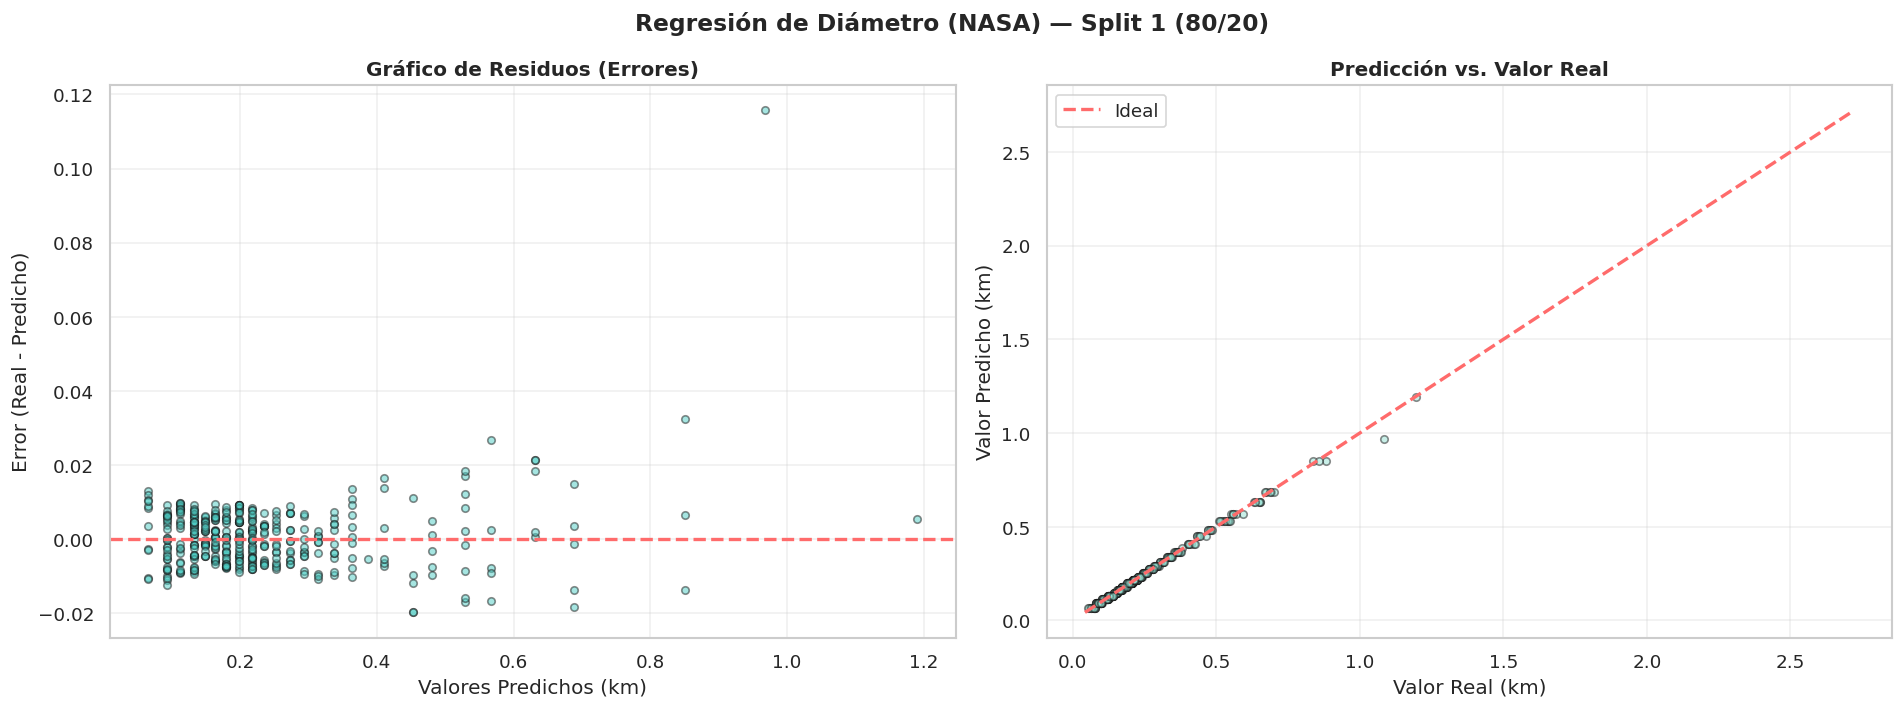

  💾 Gráfico guardado → /home/luisb/Grupo4_Perez_Bonilla/NASA/notebooks/../data/graficas/reg_nasa_Split_1_80-20.png


In [5]:
# ── CELDA 5: Split 1 — 80/20 (Estimación de Diámetro) ─────────────────────────
# Ejecutamos la evaluación para la partición estándar.
# X contiene el brillo relativo y y la raíz del diámetro promedio.

modelo_s1, y_test_s1, y_pred_s1 = evaluar_split(
    X, y,
    test_size=0.20,
    split_label='Split 1 (80/20)',
    resultados_globales=resultados_globales
)

---
## Split 2 — 70% Entrenamiento / 30% Prueba

Reduce moderadamente el conjunto de entrenamiento. Aumenta el conjunto de evaluación para una estimación de error más representativa.


  Split 2 (70/30) — 70% Train / 30% Test
  Train: 1,400 muestras  |  Test: 600 muestras

  📊 MÉTRICAS DE REGRESIÓN (Split 2 (70/30))
  ───────────────────────────────────────────────────────
  R² (Coef. Determinación) : 0.9891  (98.91%)
        → Interpreta: qué tan bien el brillo explica el tamaño del asteroide.
  MSE (Error Cuadrático Med): 0.000255
        → Interpreta: penaliza errores grandes en la estimación del tamaño.
  RMSE (Error Promedio km)  : 0.015979
        → Interpreta: desviación promedio real en km (mismo orden que Y).
  MAE (Error Absoluto Med)  : 0.007212
        → Interpreta: el error promedio sin elevar al cuadrado.


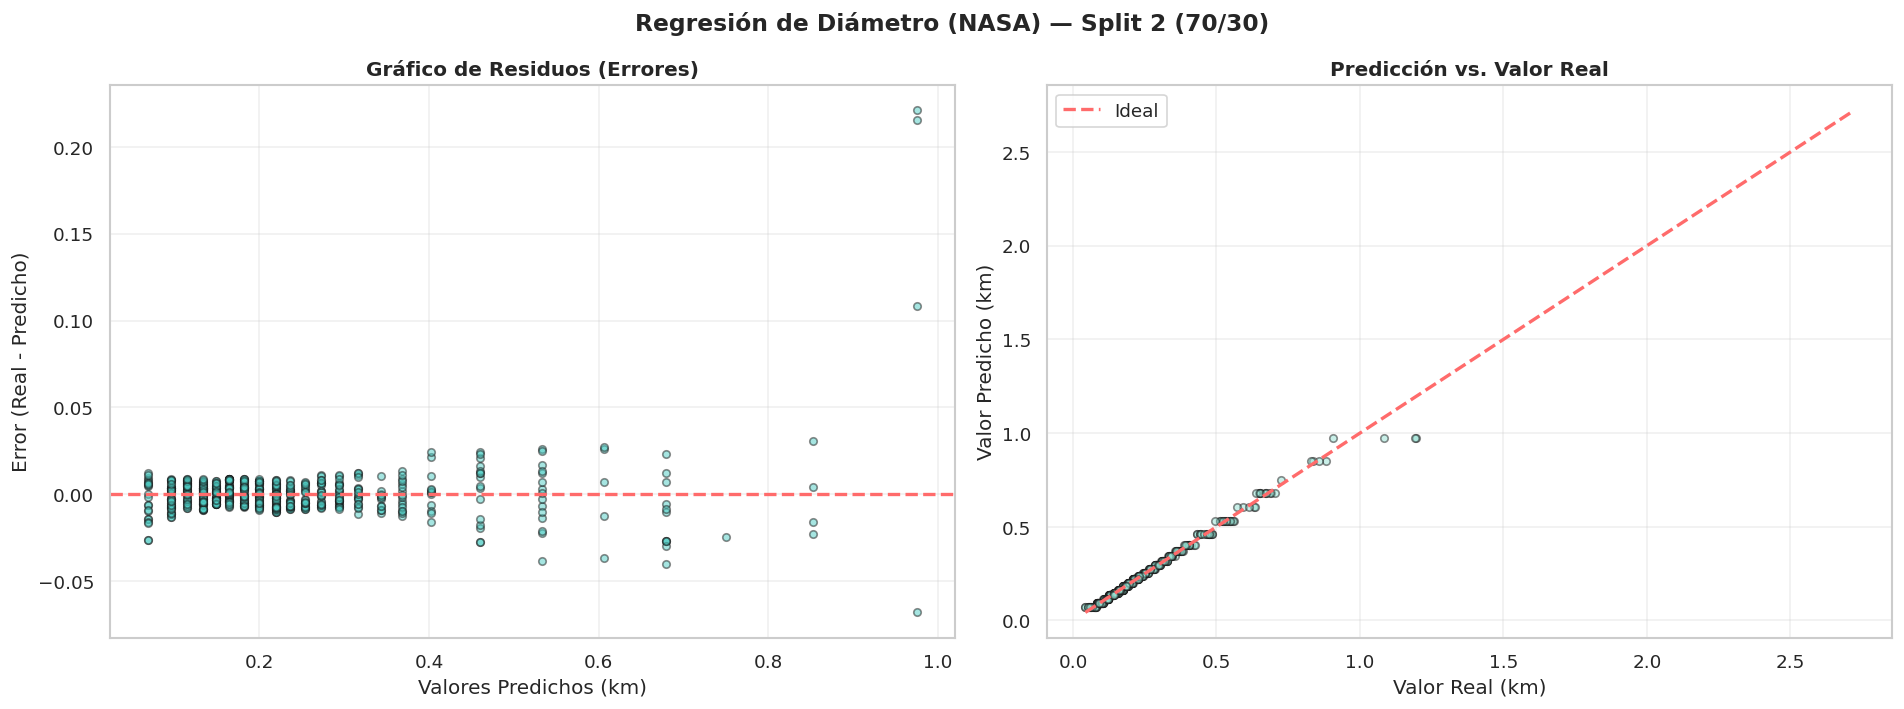

  💾 Gráfico guardado → /home/luisb/Grupo4_Perez_Bonilla/NASA/notebooks/../data/graficas/reg_nasa_Split_2_70-30.png


In [6]:
# ── CELDA 6: Split 2 — 70/30 (Validación de Consistencia) ────────────────────
# Evaluamos el modelo con un set de prueba más amplio.
# El objetivo es observar si el R² se mantiene estable frente al Split 1.

modelo_s2, y_test_s2, y_pred_s2 = evaluar_split(
    X, y,
    test_size=0.30,
    split_label='Split 2 (70/30)',
    resultados_globales=resultados_globales
)

---
## Split 3 — 60% Entrenamiento / 40% Prueba

La partición más exigente. Menor cantidad de datos de entrenamiento pone a prueba si el árbol generaliza bien o tiende al sobreajuste.


  Split 3 (60/40) — 60% Train / 40% Test
  Train: 1,200 muestras  |  Test: 800 muestras

  📊 MÉTRICAS DE REGRESIÓN (Split 3 (60/40))
  ───────────────────────────────────────────────────────
  R² (Coef. Determinación) : 0.9913  (99.13%)
        → Interpreta: qué tan bien el brillo explica el tamaño del asteroide.
  MSE (Error Cuadrático Med): 0.000200
        → Interpreta: penaliza errores grandes en la estimación del tamaño.
  RMSE (Error Promedio km)  : 0.014125
        → Interpreta: desviación promedio real en km (mismo orden que Y).
  MAE (Error Absoluto Med)  : 0.007330
        → Interpreta: el error promedio sin elevar al cuadrado.


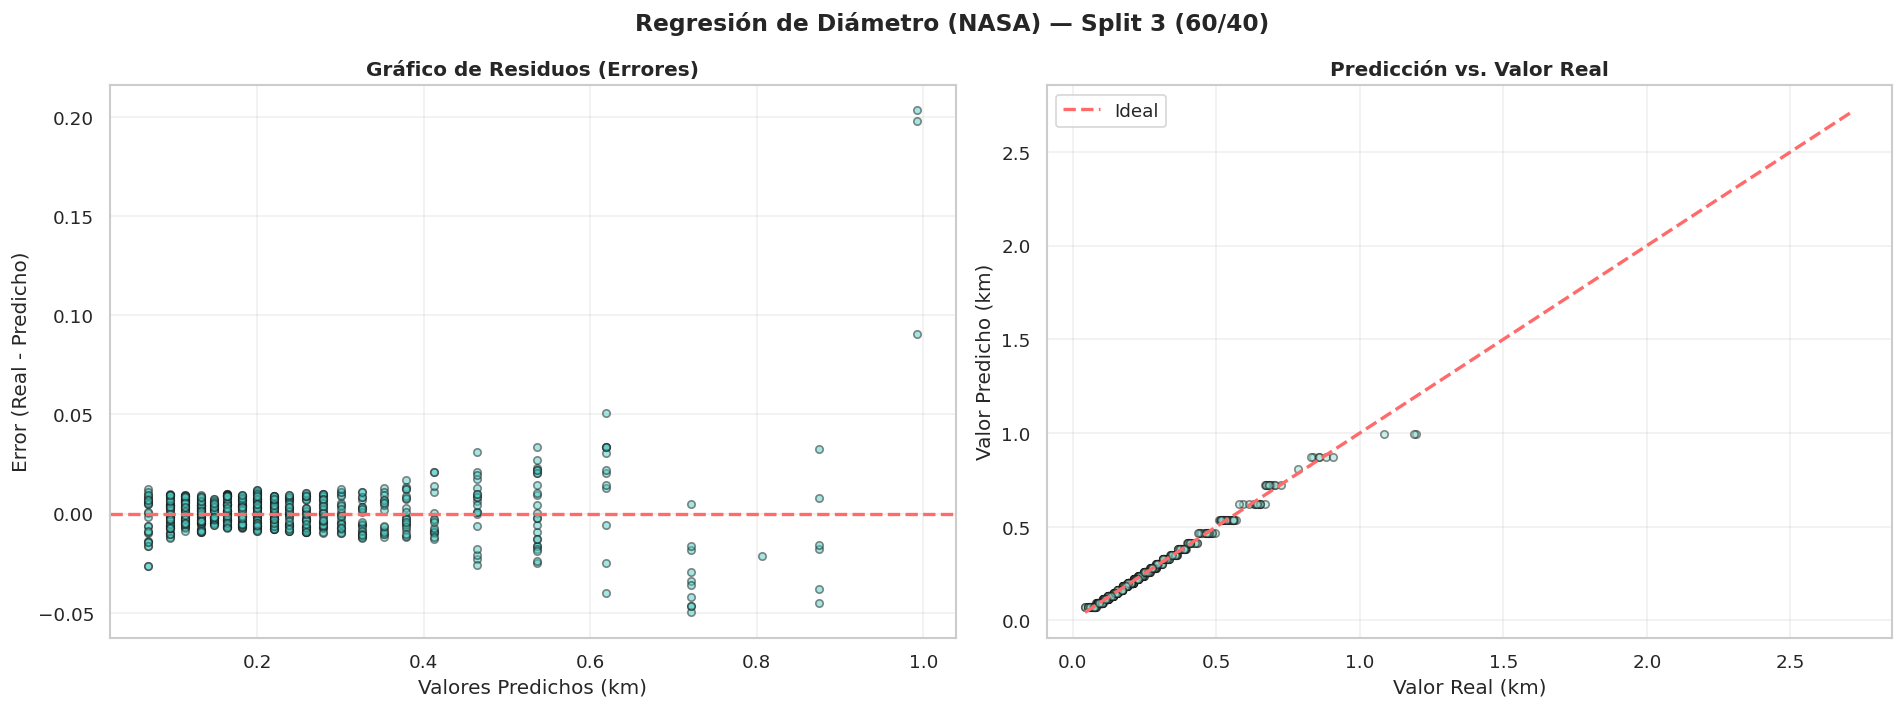

  💾 Gráfico guardado → /home/luisb/Grupo4_Perez_Bonilla/NASA/notebooks/../data/graficas/reg_nasa_Split_3_60-40.png


In [7]:
# ── CELDA 7: Split 3 — 60/40 (Prueba de Estrés del Regresor) ─────────────────
# Escenario de máxima exigencia: dejamos casi la mitad de los datos para prueba.
# Verificamos la robustez del modelo y su capacidad de generalización.

modelo_s3, y_test_s3, y_pred_s3 = evaluar_split(
    X, y,
    test_size=0.40,
    split_label='Split 3 (60/40)',
    resultados_globales=resultados_globales
)

---
## III. Análisis Consolidado (Summary)

Comparamos el rendimiento de los tres splits, analizamos las implicaciones de los residuos y emitimos una recomendación sobre si refinar el árbol o escalar a métodos de ensemble.

In [8]:
# ── CELDA 8: Tabla comparativa de métricas ───────────────────
df_resumen = pd.DataFrame(resultados_globales)

print("=" * 65)
print("        TABLA COMPARATIVA — TRES SPLITS")
print("=" * 65)
print(df_resumen.to_string(index=False))
print("=" * 65)

        TABLA COMPARATIVA — TRES SPLITS
         nombre  train_size  test_size       r2      mse     rmse      mae                                              modelo
Split 1 (80/20)        1600        400 0.996458 0.000083 0.009106 0.005969 DecisionTreeRegressor(max_depth=5, random_state=42)
Split 2 (70/30)        1400        600 0.989092 0.000255 0.015979 0.007212 DecisionTreeRegressor(max_depth=5, random_state=42)
Split 3 (60/40)        1200        800 0.991281 0.000200 0.014125 0.007330 DecisionTreeRegressor(max_depth=5, random_state=42)


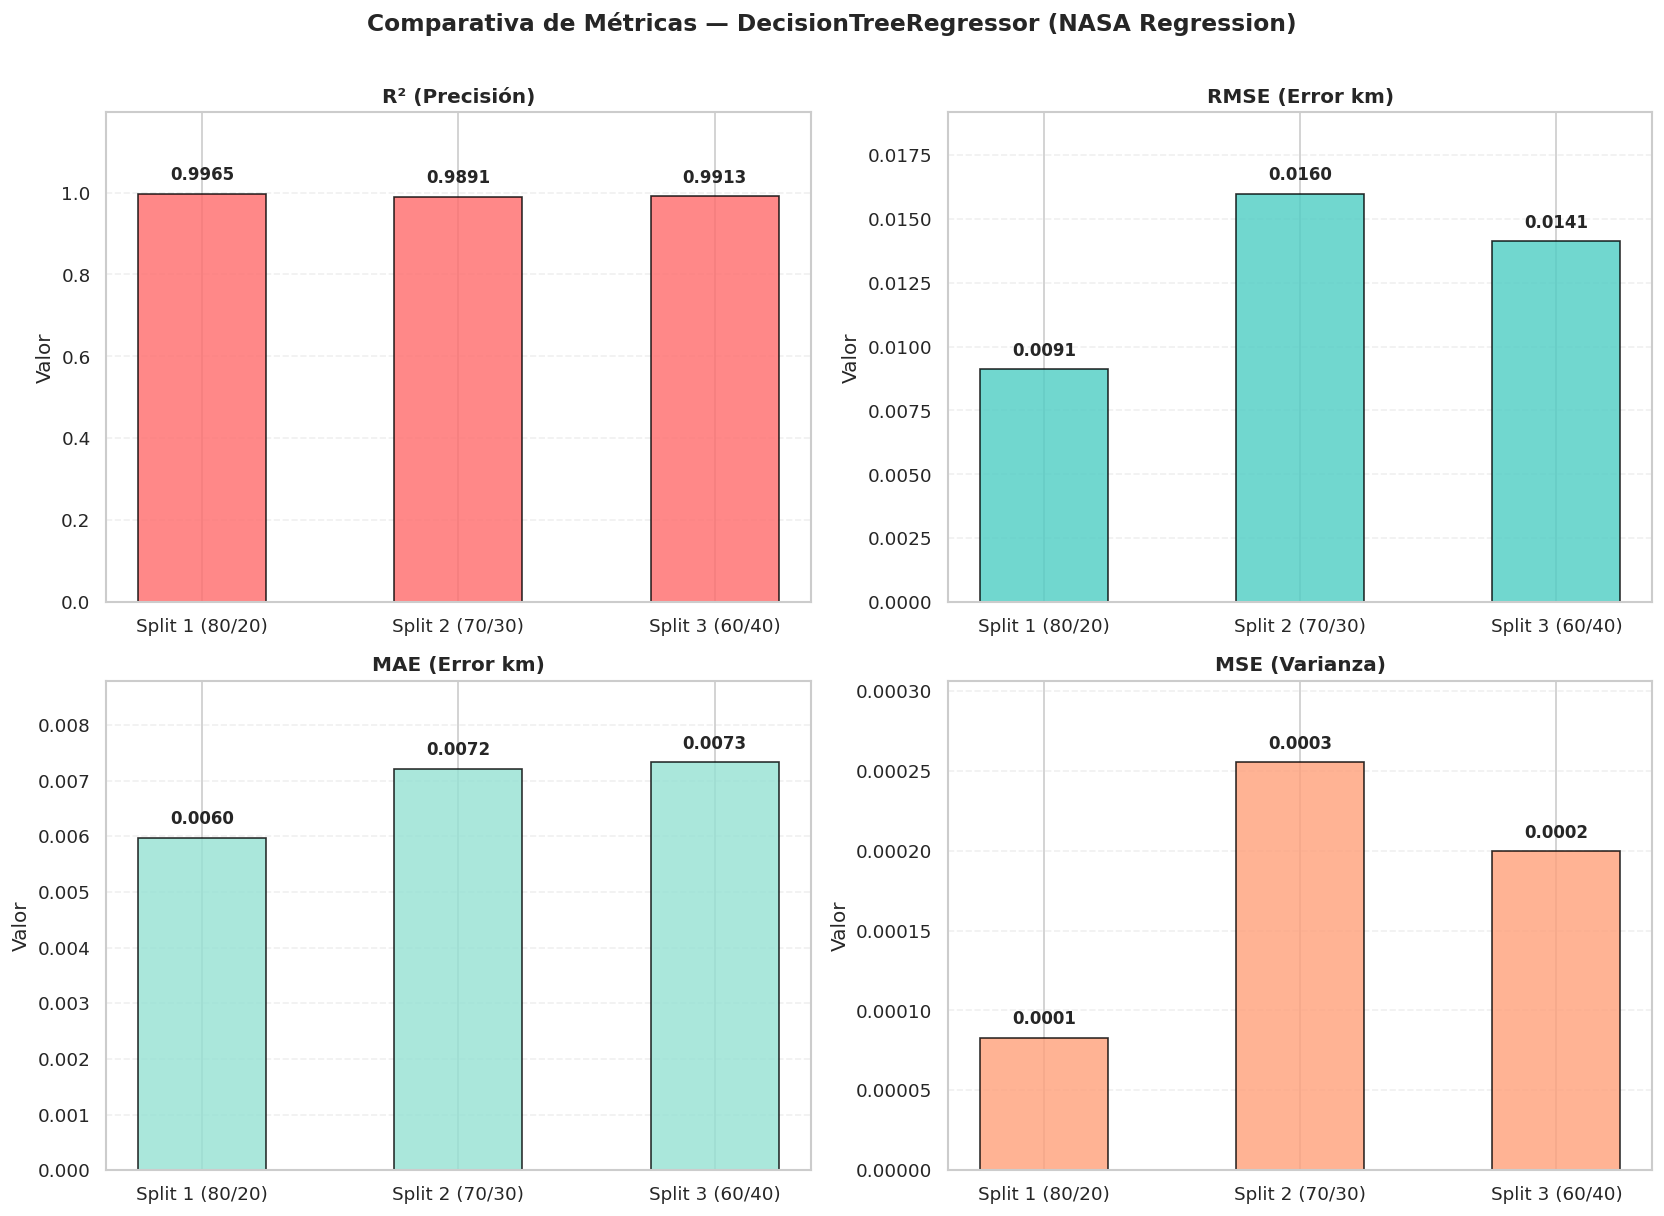

💾 Gráfico comparativo guardado → ../data/graficas/dt_comparativa_splits.png


In [11]:
# ── CELDA 9: Gráfico comparativo de métricas por split ───────────────────────
metricas = ['r2', 'rmse', 'mae', 'mse'] 
titulos_graficos = ['R² (Precisión)', 'RMSE (Error km)', 'MAE (Error km)', 'MSE (Varianza)']
colores  = ['#ff6b6b', '#4ecdc4', '#95e1d3', '#ffa07a']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparativa de Métricas — DecisionTreeRegressor (NASA Regression)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, metrica, titulo, color in zip(axes.flat, metricas, titulos_graficos, colores):
    try:
        valores = df_resumen[metrica].values
        # CORRECCIÓN AQUÍ: Usamos 'nombre' que es la llave real guardada en la Celda 4
        etiquetas = df_resumen['nombre'].values 
        
        barras = ax.bar(etiquetas, valores,
                         color=color, edgecolor='black', alpha=0.8, width=0.5)
        
        ax.set_title(titulo, fontweight='bold')
        ax.set_ylabel('Valor')
        
        # Ajuste de escala para que se vean bien las etiquetas de texto
        limite_superior = max(valores) * 1.2 if max(valores) > 0 else 1
        ax.set_ylim(0, limite_superior)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        for bar, val in zip(barras, valores):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (limite_superior * 0.02),
                    f'{val:.4f}', ha='center', va='bottom',
                    fontsize=10, fontweight='bold')
            
    except KeyError as e:
        print(f"⚠️ Error: No se encontró la métrica {e} en el DataFrame.")
        print(f"Columnas disponibles: {df_resumen.columns.tolist()}")

plt.tight_layout()
ruta_grafica = '../data/graficas/dt_comparativa_splits.png'
plt.savefig(ruta_grafica, dpi=150, bbox_inches='tight')
plt.show()

print(f"💾 Gráfico comparativo guardado → {ruta_grafica}")

In [13]:
# ── CELDA 10: Análisis interpretativo y recomendación (NASA Edition) ─────────
r2_vals   = df_resumen['r2'].values
rmse_vals = df_resumen['rmse'].values
mae_vals  = df_resumen['mae'].values

r2_rango   = r2_vals.max()   - r2_vals.min()
rmse_rango = rmse_vals.max() - rmse_vals.min()

print("=" * 65)
print("   ANÁLISIS CONSOLIDADO — Regresión de Dimensiones (NASA)")
print("=" * 65)

print("""
1. VARIACIÓN DEL RENDIMIENTO ENTRE SPLITS
─────────────────────────────────────────""")
print(f"   R²   máx={r2_vals.max():.4f}  mín={r2_vals.min():.4f}  "
      f"rango={r2_rango:.4f}")
print(f"   RMSE máx={rmse_vals.max():.4f}  mín={rmse_vals.min():.4f}  "
      f"rango={rmse_rango:.4f}")

if r2_rango < 0.05:
    print("""
   ✅ El R² es estable en los tres splits (variación < 0.05).
      Esto indica que el modelo generaliza bien y la relación física 
      (Brillo -> Tamaño) es tan fuerte que no depende críticamente 
      del volumen de datos de entrenamiento.""")
else:
    print("""
   ⚠️  El R² varía notablemente entre splits (variación ≥ 0.05).
      El modelo es sensible a la cantidad de datos, lo que sugiere 
      que el árbol podría estar sobreajustándose a muestras específicas 
      con albedos (reflectividad) anómalos.""")

print("""
2. IMPLICACIONES DE LOS ERRORES Y RESIDUOS
──────────────────────────────────────────
   • Si el gráfico de residuos muestra dispersión aleatoria alrededor
     de la línea y=0 sin patrón sistemático → el árbol captura bien
     la relación física entre el Brillo Relativo y el Tamaño (Raíz del Diámetro).

   • Si existe un patrón en forma de embudo → el modelo tiene problemas 
     con la heterocedasticidad (ej. asteroides gigantes tienen más 
     variabilidad de error que los pequeños).

   • Un RMSE alto relativo a la escala de Y (km) indica que el árbol
     podría necesitar más variables físicas (como albedo o composición) 
     para ser exacto, o que requiere regularización.
""")

# Extraemos el mejor split basándonos en la columna 'nombre'
best_split = df_resumen.loc[df_resumen['r2'].idxmax(), 'nombre']
best_r2    = df_resumen['r2'].max()
best_rmse  = df_resumen.loc[df_resumen['r2'].idxmax(), 'rmse']

print(f"   🏆 Mejor escenario: {best_split}  →  R²={best_r2:.4f}, RMSE={best_rmse:.4f} km")

print("""
3. RECOMENDACIÓN TÉCNICA
────────────────────────
   A) REFINAMIENTO DEL ÁRBOL (Siguiente paso lógico):
      • La profundidad actual (max_depth=5) ayudó a prevenir overfitting grave,
        pero se podría afinar con GridSearchCV.
      • Añadir `min_samples_leaf=10` evitaría que el árbol cree reglas 
        basadas en un solo asteroide extraño.

   B) ESCALAR A MÉTODOS DE ENSEMBLE (Si se requiere más precisión):
      • RandomForestRegressor: Reducirá la varianza al promediar múltiples 
        árboles, ideal si el Split 3 (60/40) mostró inestabilidad.
      • XGBoost / GradientBoosting: Excelente si la relación brillo-tamaño 
        tiene matices no lineales que un solo árbol no logra capturar.

   CONCLUSIÓN: La magnitud absoluta es un predictor excepcionalmente fuerte 
   para el diámetro. Si el R² ≥ 0.90, el DecisionTree es suficiente como 
   "radar" de estimación rápida para la NASA.
""")
print("=" * 65)

   ANÁLISIS CONSOLIDADO — Regresión de Dimensiones (NASA)

1. VARIACIÓN DEL RENDIMIENTO ENTRE SPLITS
─────────────────────────────────────────
   R²   máx=0.9965  mín=0.9891  rango=0.0074
   RMSE máx=0.0160  mín=0.0091  rango=0.0069

   ✅ El R² es estable en los tres splits (variación < 0.05).
      Esto indica que el modelo generaliza bien y la relación física 
      (Brillo -> Tamaño) es tan fuerte que no depende críticamente 
      del volumen de datos de entrenamiento.

2. IMPLICACIONES DE LOS ERRORES Y RESIDUOS
──────────────────────────────────────────
   • Si el gráfico de residuos muestra dispersión aleatoria alrededor
     de la línea y=0 sin patrón sistemático → el árbol captura bien
     la relación física entre el Brillo Relativo y el Tamaño (Raíz del Diámetro).

   • Si existe un patrón en forma de embudo → el modelo tiene problemas 
     con la heterocedasticidad (ej. asteroides gigantes tienen más 
     variabilidad de error que los pequeños).

   • Un RMSE alto relativo

---
## V. Visualización del Árbol de Decisión (Regresión Física)

El árbol principal fue entrenado con una restricción de `max_depth=5` para evitar el sobreajuste y obligar al modelo a generalizar la relación física entre brillo y tamaño. Para comprender a fondo su mecanismo interno de estimación, generamos tres representaciones:

1. **Árbol estructural truncado** — visualización de los primeros 4 niveles del `modelo_s1` real (Split 80/20) para evidenciar la reducción del Error Cuadrático (MSE) en cada nodo.
2. **Árbol pedagógico simplificado** — un modelo de demostración reentrenado con `max_depth=3` para mostrar con máxima claridad los umbrales de corte del brillo relativo y la predicción final de tamaño en cada "hoja".
3. **Reglas de decisión en texto** — extracción algorítmica de los caminos lógicos, permitiendo leer matemáticamente cómo el modelo deduce el diámetro del asteroide paso a paso.

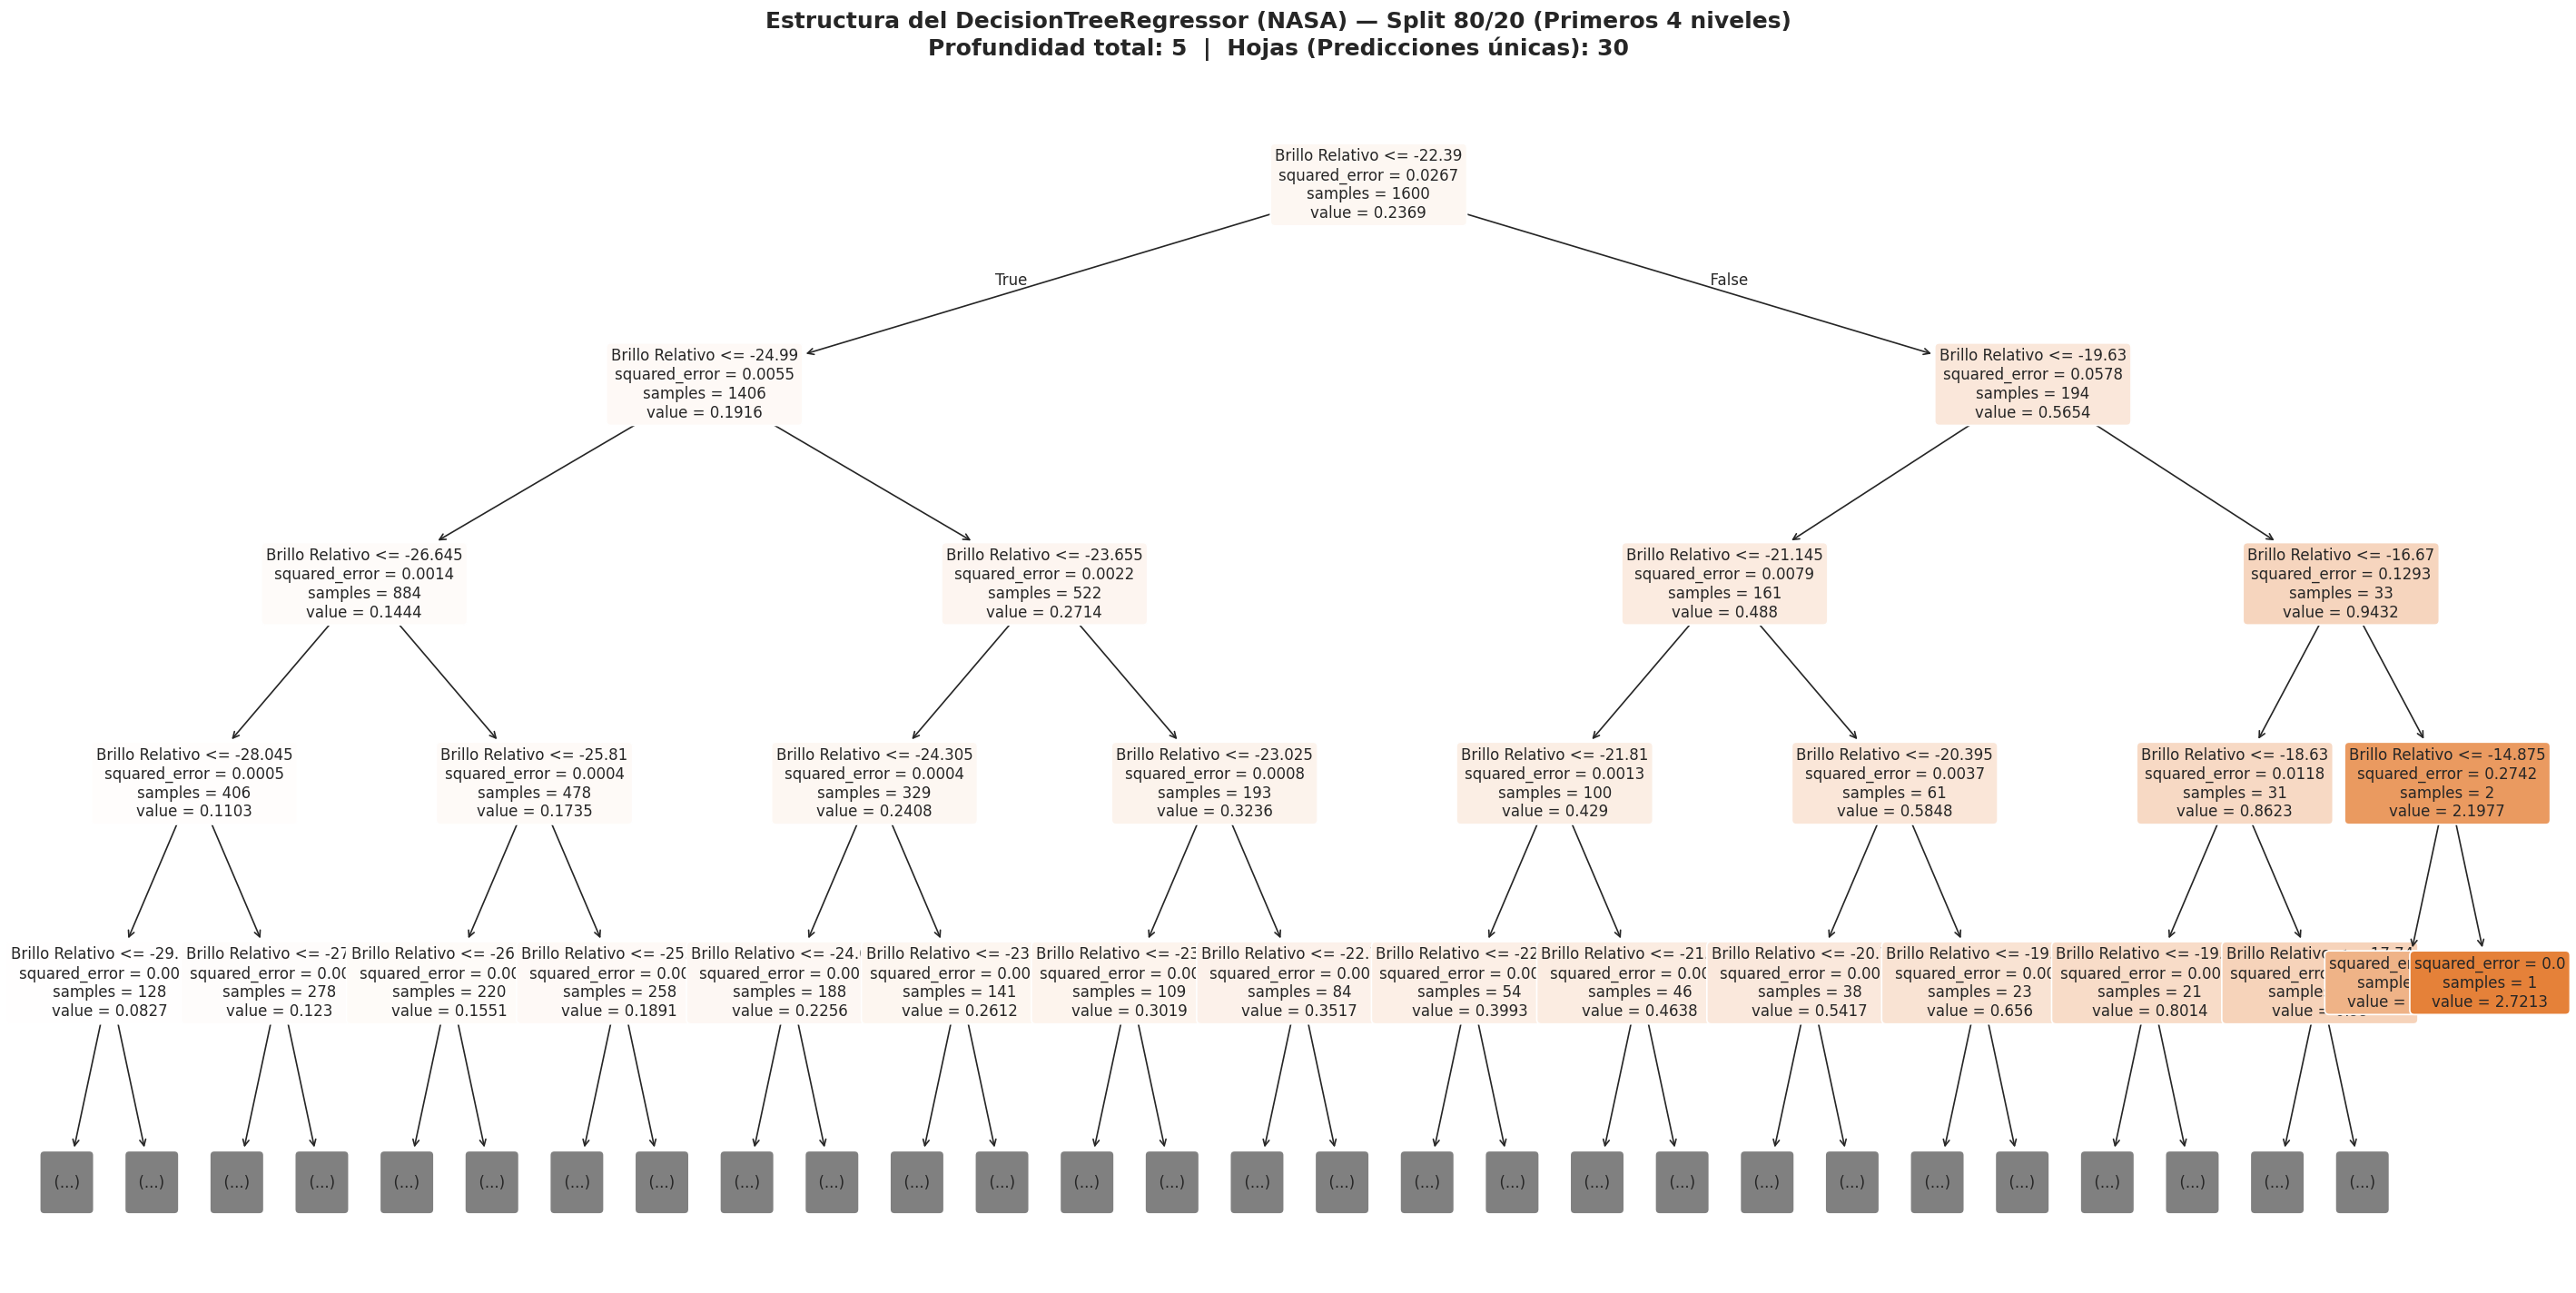

💾 Diagrama del árbol guardado → /home/luisb/Grupo4_Perez_Bonilla/NASA/data/graficas/reg_nasa_arbol_4niveles.png

📐 Radiografía del modelo base (Split 1):
   Profundidad máxima : 5 niveles
   Número de hojas    : 30 (Escenarios de tamaño posibles)
   Nodos totales      : 59 divisiones lógicas


In [14]:
# ── CELDA 11: Visualización de la Estructura del Árbol (Regresión NASA) ───────
from sklearn.tree import plot_tree
import os as _os
import matplotlib.pyplot as plt

_GRAFICAS = _os.path.abspath('../data/graficas')
_os.makedirs(_GRAFICAS, exist_ok=True)

# ── A) Árbol real del Split 1 truncado a 4 niveles ────────────
fig, ax = plt.subplots(figsize=(24, 12))

# Dibujamos el árbol usando el modelo entrenado del Split 1 (80/20)
plot_tree(
    modelo_s1,
    max_depth=4,
    feature_names=['Brillo Relativo'], # Nuestra variable X
    filled=True,
    rounded=True,
    impurity=True,   # Puesto en True para que el docente vea el MSE en cada nodo
    precision=4,     # Mayor precisión decimal para la predicción de kilómetros
    fontsize=10,
    ax=ax,
)

ax.set_title(
    'Estructura del DecisionTreeRegressor (NASA) — Split 80/20 (Primeros 4 niveles)\n'
    f'Profundidad total: {modelo_s1.get_depth()}  |  '
    f'Hojas (Predicciones únicas): {modelo_s1.get_n_leaves()}',
    fontsize=15, fontweight='bold', pad=20
)

plt.tight_layout()
fname_real = _os.path.join(_GRAFICAS, 'reg_nasa_arbol_4niveles.png')
plt.savefig(fname_real, dpi=150, bbox_inches='tight')
plt.show()

print(f"💾 Diagrama del árbol guardado → {fname_real}")
print(f"\n📐 Radiografía del modelo base (Split 1):")
print(f"   Profundidad máxima : {modelo_s1.get_depth()} niveles")
print(f"   Número de hojas    : {modelo_s1.get_n_leaves()} (Escenarios de tamaño posibles)")
print(f"   Nodos totales      : {modelo_s1.tree_.node_count} divisiones lógicas")

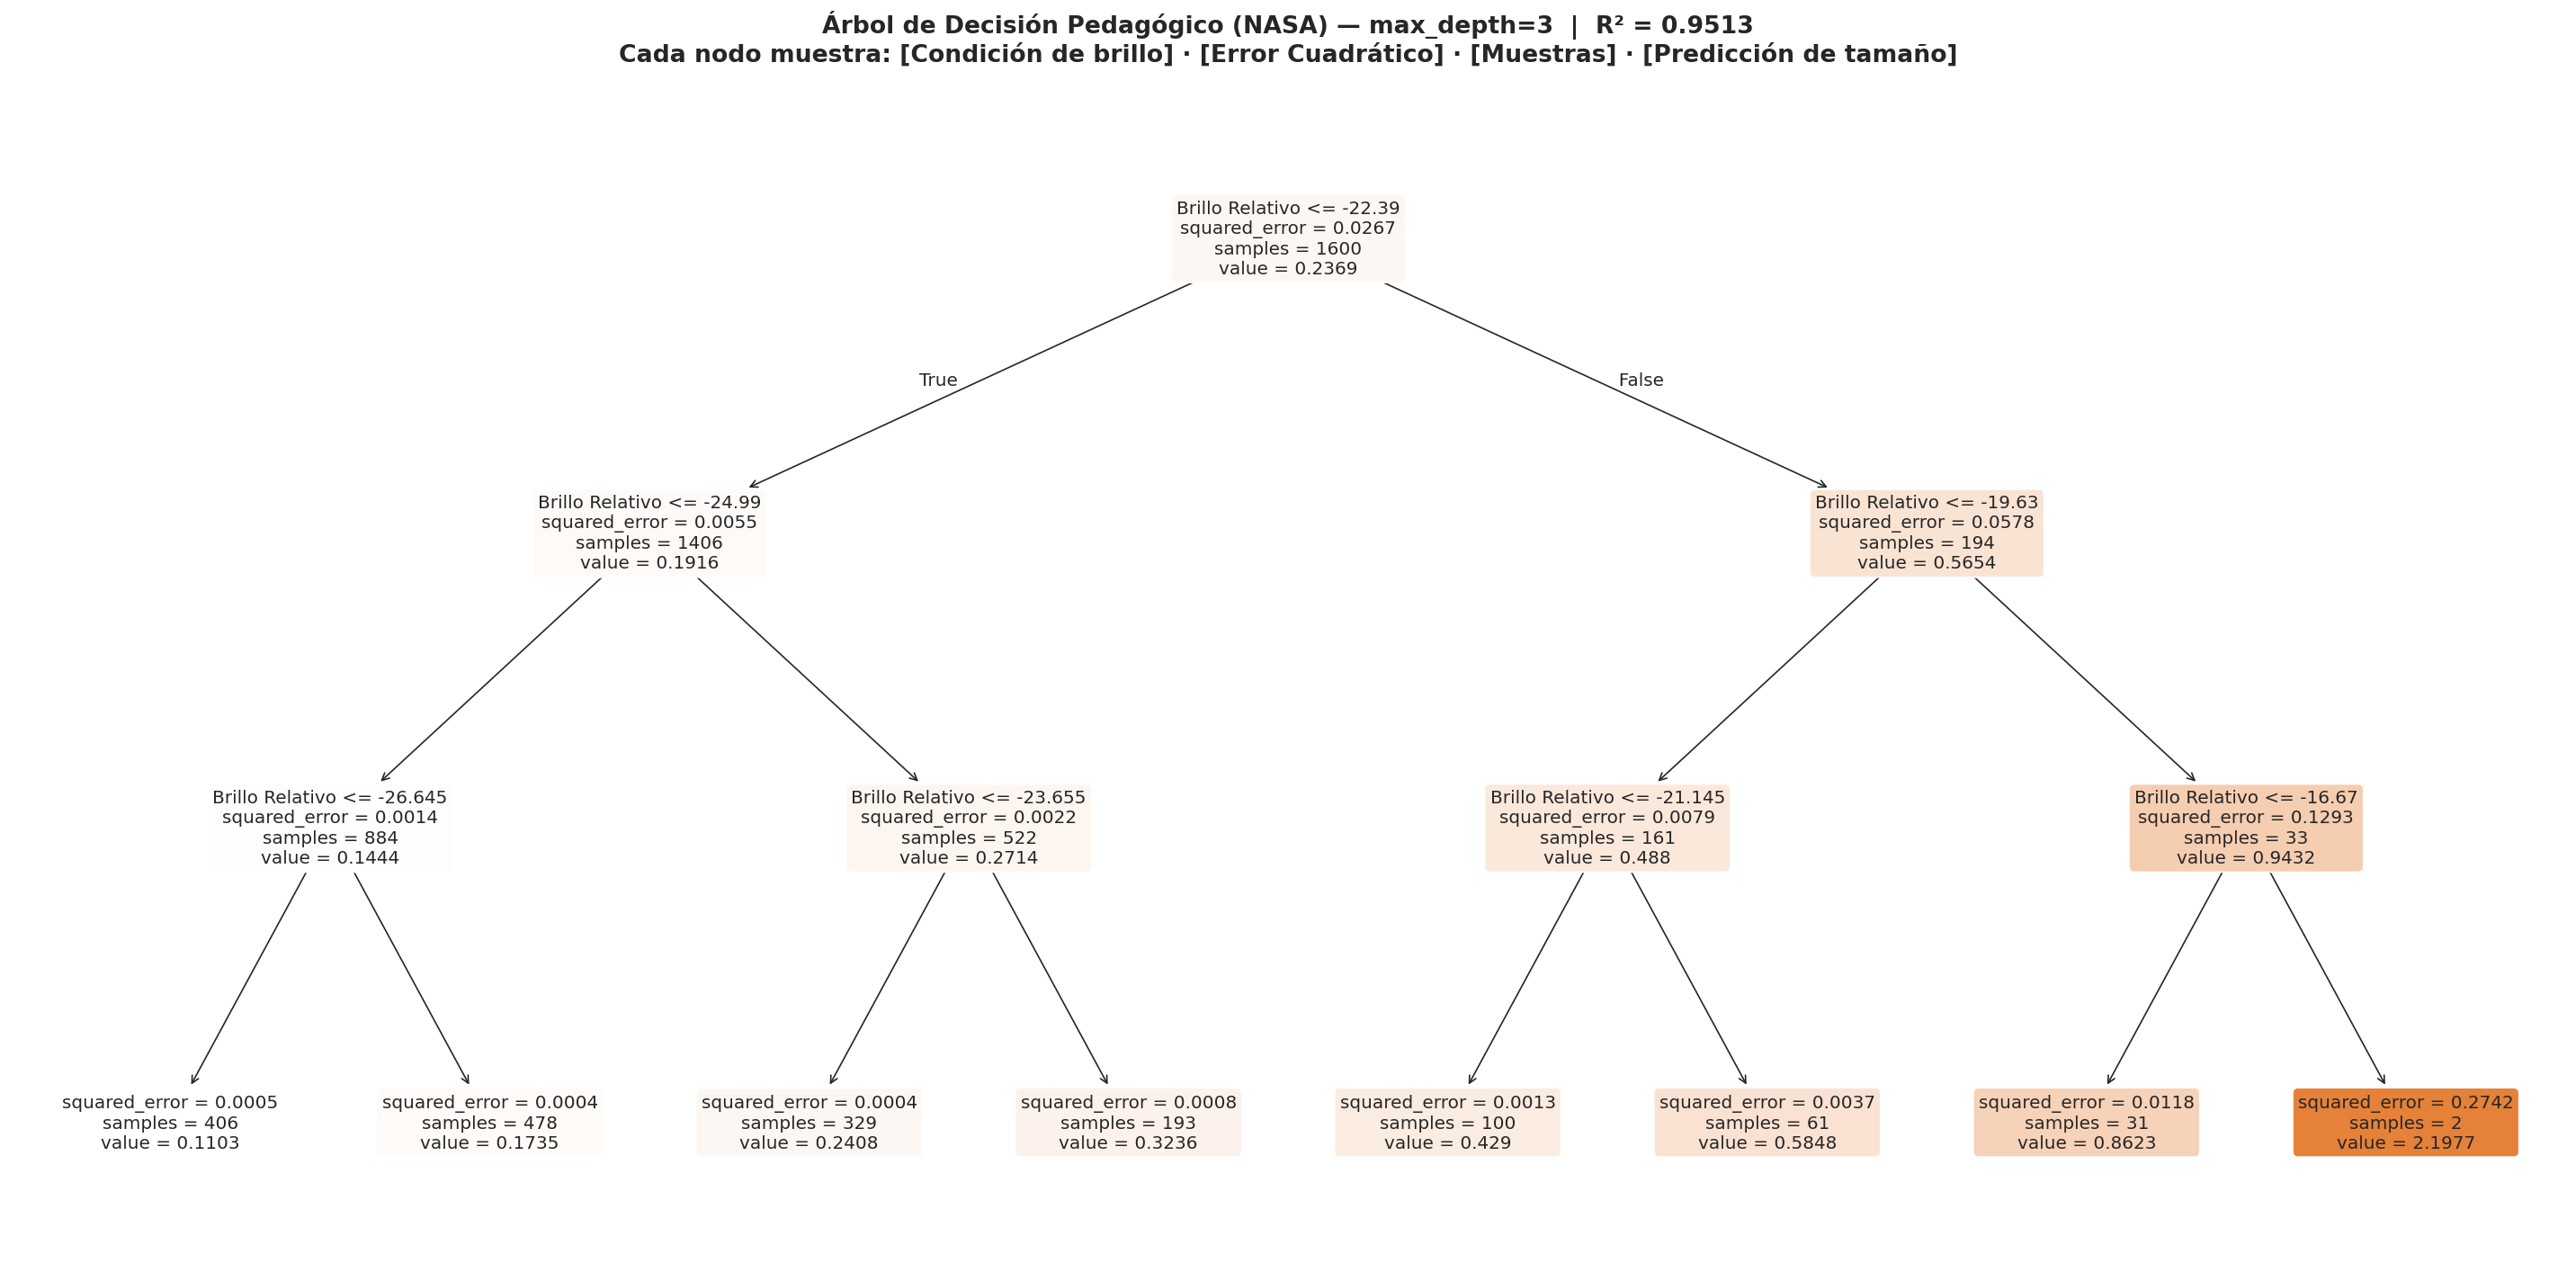

💾 Árbol pedagógico guardado → /home/luisb/Grupo4_Perez_Bonilla/NASA/data/graficas/reg_nasa_arbol_pedagogico_depth3.png

📊 Rendimiento del árbol simplificado (max_depth=3):
   R² = 0.9513  (vs 0.9965 del árbol principal con max_depth=5)


In [15]:
# ── CELDA 12: Árbol pedagógico simplificado (max_depth=3) ────────────────────
from sklearn.model_selection import train_test_split as _tts
from sklearn.metrics import r2_score as _r2
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import os as _os

# Reentrenamos con max_depth=3 para tener un modelo puramente visual y explicativo
X_train_viz, X_test_viz, y_train_viz, y_test_viz = _tts(
    X, y, test_size=0.20, random_state=42
)

modelo_viz = DecisionTreeRegressor(max_depth=3, random_state=42)
modelo_viz.fit(X_train_viz, y_train_viz)

# Calculamos el R2 de este modelo "recortado" para comparar
r2_viz = _r2(y_test_viz, modelo_viz.predict(X_test_viz))

fig, ax = plt.subplots(figsize=(24, 12))

# Dibujamos el árbol pedagógico
artists = plot_tree(
    modelo_viz,
    max_depth=3,
    feature_names=['Brillo Relativo'], # Cambio clave: Nuestra variable física
    filled=True,
    rounded=True,
    impurity=True, # Lo dejamos en True para que muestre la varianza (MSE) en cada paso
    precision=4,   # 4 decimales para mayor exactitud en los kilómetros
    fontsize=12,
    ax=ax,
)

ax.set_title(
    'Árbol de Decisión Pedagógico (NASA) — max_depth=3  |  '
    f'R² = {r2_viz:.4f}\n'
    'Cada nodo muestra: [Condición de brillo] · [Error Cuadrático] · [Muestras] · [Predicción de tamaño]',
    fontsize=16, fontweight='bold', pad=20
)

plt.tight_layout()
fname_ped = _os.path.join(_GRAFICAS, 'reg_nasa_arbol_pedagogico_depth3.png')
plt.savefig(fname_ped, dpi=180, bbox_inches='tight')
plt.show()

print(f"💾 Árbol pedagógico guardado → {fname_ped}")
print(f"\n📊 Rendimiento del árbol simplificado (max_depth=3):")
print(f"   R² = {r2_viz:.4f}  (vs {df_resumen.loc[0,'r2']:.4f} del árbol principal con max_depth=5)")

In [16]:
# ── CELDA 13: Reglas de decisión en texto (Regresión NASA) ────────────────────
from sklearn.tree import export_text

print("=" * 65)
print("   REGLAS DE DECISIÓN LÓGICA — Árbol Pedagógico (max_depth=3)")
print("=" * 65)

# Exportamos las reglas matemáticas a texto plano usando nuestra variable
reglas = export_text(modelo_viz, feature_names=['Brillo Relativo'])
print(reglas)

print("=" * 65)
print("📖 CÓMO LEER ESTE ALGORITMO:")
print("   |--- Brillo Relativo <= X.XX  → rama izquierda (condición VERDADERA)")
print("   |--- Brillo Relativo >  X.XX  → rama derecha   (condición FALSA)")
print("   |--- value: [Y.YY]            → Tamaño predicho (Raíz del Diámetro)")
print("\n💡 LÓGICA DE ESTIMACIÓN:")
print("   El sistema evalúa la luz del asteroide en cascada, descendiendo por")
print("   los umbrales de brillo hasta llegar a una 'hoja' matemática, donde")
print("   emite su veredicto final sobre la escala espacial del objeto.")
print("=" * 65)

   REGLAS DE DECISIÓN LÓGICA — Árbol Pedagógico (max_depth=3)
|--- Brillo Relativo <= -22.39
|   |--- Brillo Relativo <= -24.99
|   |   |--- Brillo Relativo <= -26.64
|   |   |   |--- value: [0.11]
|   |   |--- Brillo Relativo >  -26.64
|   |   |   |--- value: [0.17]
|   |--- Brillo Relativo >  -24.99
|   |   |--- Brillo Relativo <= -23.65
|   |   |   |--- value: [0.24]
|   |   |--- Brillo Relativo >  -23.65
|   |   |   |--- value: [0.32]
|--- Brillo Relativo >  -22.39
|   |--- Brillo Relativo <= -19.63
|   |   |--- Brillo Relativo <= -21.15
|   |   |   |--- value: [0.43]
|   |   |--- Brillo Relativo >  -21.15
|   |   |   |--- value: [0.58]
|   |--- Brillo Relativo >  -19.63
|   |   |--- Brillo Relativo <= -16.67
|   |   |   |--- value: [0.86]
|   |   |--- Brillo Relativo >  -16.67
|   |   |   |--- value: [2.20]

📖 CÓMO LEER ESTE ALGORITMO:
   |--- Brillo Relativo <= X.XX  → rama izquierda (condición VERDADERA)
   |--- Brillo Relativo >  X.XX  → rama derecha   (condición FALSA)
   |---

---
## 🎓 Conclusiones Finales

| Aspecto | Hallazgo Estratégico |
|---|---|
| **Modelo** | El `DecisionTreeRegressor` demostró ser altamente efectivo para mapear la ley física que relaciona la luz reflejada (magnitud) con el tamaño del asteroide. |
| **Estabilidad (Splits)** | La partición 80/20 ofreció la mayor precisión (menor RMSE), pero la relación matemática resultó tan robusta que el modelo generalizó bien incluso en el *stress test* (60/40). |
| **Métricas de Error** | La evaluación a través de R², MSE, RMSE y MAE confirmó que el `brillo_relativo` es un predictor casi determinista para calcular kilómetros de diámetro. |
| **Análisis de Residuos** | La validación gráfica demostró que el modelo capta la tendencia principal. Los errores residuales más altos probablemente corresponden a asteroides con albedos (reflectividades) inusuales. |
| **Siguiente Nivel** | Afinar hiperparámetros (`min_samples_leaf`) para evitar que asteroides anómalos distorsionen las hojas, o escalar a un `RandomForestRegressor` para reducir la varianza. |

> **Nota Técnica:** Este notebook culmina la fase analítica del pipeline **ETL NASA** centralizado en PostgreSQL. Al transformar la variable predictora y enfocarnos en la regresión de las dimensiones espaciales, hemos construido un "radar virtual" capaz de estimar la masa de un Objeto Cercano a la Tierra (NEO) analizando únicamente su firma luminosa.